In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial


# local imports
import sys
# sys.path.append('../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
import matplotlib as mpl
plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [22]:
from pyanalib.split_df_helpers_new import *

## WireMod comparison — matched events

Compare reconstructed distributions between WireMod variations for events that survive the selection in **all** datasets (matched events).

**Workflow**
1. Define variable extractors and bin edges.
2. Loop through matched `.df` files **one at a time**, accumulate histogram counts (no large in-memory concat).
3. After all files are processed, make comparison plots.

In [ ]:
import glob as glob_module
import gc

from analysis_village.numucc_1p0pi.selection_framework import multicol_get_series
from makedf.util import avg_chi2 as _raw_avg_chi2

# ── Matched file locations ────────────────────────────────────────────────────

_YZ_DIR   = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_09_223419__sel_2prong-mc-BNB_cosmics-WireModYZ/merged_perTPC"
_XTXW_DIR = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_161556__sel_2prong-mc-BNB_cosmics-WireModXTXW/merged_perTPC"
_CV_DIR   = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_190744__sel_2prong-mc-BNB_cosmics-calovar/merged_perTPC"

yz_matched   = sorted(glob_module.glob(path.join(_YZ_DIR,   "*sel_2prong*_matched.df")))
xtxw_matched = sorted(glob_module.glob(path.join(_XTXW_DIR, "*sel_2prong*_matched.df")))
cv_matched   = sorted(glob_module.glob(path.join(_CV_DIR,   "*sel_2prong*_matched.df")))

VARIATIONS = {
    "YZ":   yz_matched,
    "XTXW": xtxw_matched,
    "CV":   cv_matched,
}

# All calo universes in matched files: evt_cv + evt_<param>_{p,m}
CALO_PARAMS = ("ccal", "alpha", "beta", "R")
ALL_UNIVERSES = ("cv",) + tuple(f"{c}_{s}" for c in CALO_PARAMS for s in ("p", "m"))
UNIVERSES_TO_PLOT = list(ALL_UNIVERSES)

# Output: cached histograms + saved figures
OUT_DIR = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/wiremod_comparison"
CACHE_PATH = path.join(OUT_DIR, "wiremod_matched_hists.pkl")
FIG_DIR = path.join(OUT_DIR, "figures")
makedirs(OUT_DIR, exist_ok=True)
makedirs(FIG_DIR, exist_ok=True)

print("Matched file counts:")
for name, files in VARIATIONS.items():
    print(f"  {name}: {len(files)} files")
print(f"Cache: {CACHE_PATH}")
print(f"Figures: {FIG_DIR}")

Matched file counts:
  YZ: 88 files
  XTXW: 1202 files
  CV: 84 files
Cache: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/wiremod_comparison/wiremod_matched_hists.pkl
Figures: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/wiremod_comparison/figures


In [24]:
# ── Variable definitions ──────────────────────────────────────────────────────
#
# Each entry: name -> dict with keys:
#   label    : axis label
#   bins     : 1-D bin-edge array
#   extract  : callable(evt_df) -> 1-D np.ndarray of values to histogram
#              evt_df has trk1 / trk2 as top-level column groups
#
# Per-track variables are extracted from trk1 + trk2 concatenated.
# Per-event variables are extracted directly from the evt df.

def _safe_avg_chi2(trk_df, chi2_name):
    """Average per-plane chi2 over planes I0/I1/I2; return empty array on error."""
    try:
        return _raw_avg_chi2(trk_df, chi2_name).to_numpy(dtype=float)
    except Exception:
        return np.array([], dtype=float)


def _per_trk(evt_df, fn):
    """Apply fn to trk1 and trk2 sub-dfs, concatenate, return float array."""
    out = []
    top_cols = evt_df.columns.get_level_values(0).unique()
    for trk in ("trk1", "trk2"):
        if trk not in top_cols:
            continue
        try:
            vals = np.asarray(fn(evt_df[trk]), dtype=float)
            if vals.ndim == 1:
                out.append(vals)
        except Exception:
            pass
    return np.concatenate(out) if out else np.array([], dtype=float)


def _per_trk_col(evt_df, col_tuple):
    """Extract a MultiIndex column from each track and concatenate."""
    return _per_trk(
        evt_df,
        lambda t: multicol_get_series(t, col_tuple).to_numpy(dtype=float),
    )


def _per_evt_col(evt_df, col_tuple):
    try:
        return multicol_get_series(evt_df, col_tuple).to_numpy(dtype=float)
    except Exception:
        return np.array([], dtype=float)


VAR_DEFS = {
    # ── chi2 (priority variables) ─────────────────────────────────────────
    "chi2_mu": {
        "label": r"$\langle\chi^2_\mu\rangle$ (per track)",
        "bins":  np.linspace(0, 55, 56),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_muon_new")),
    },
    "chi2_p": {
        "label": r"$\langle\chi^2_p\rangle$ (per track)",
        "bins":  np.linspace(0, 300, 61),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_proton_new")),
    },
    # ── track shape ───────────────────────────────────────────────────────
    "track_score": {
        "label": "PFP Track Score (per track)",
        "bins":  np.linspace(0.2, 1.0, 41),
        "extract": lambda df: _per_trk_col(df, ("pfp", "trackScore", "", "", "", "")),
    },
    "trk_len": {
        "label": "Track Length (cm, per track)",
        "bins":  np.linspace(0, 200, 41),
        "extract": lambda df: _per_trk_col(df, ("pfp", "trk", "len", "", "", "")),
    },
    "vtx_dist": {
        "label": "Vertex Distance (cm, per track)",
        "bins":  np.linspace(0, 6, 41),
        "extract": lambda df: _per_trk_col(df, ("pfp", "pfochar", "vtxdist", "", "", "")),
    },
    # ── kinematics ────────────────────────────────────────────────────────
    "muon_p": {
        "label": r"$P_\mu$ (GeV/c)",
        "bins":  np.linspace(0.1, 1.2, 45),
        "extract": lambda df: _per_evt_col(df, ("mu", "pfp", "trk", "P", "p_muon", "", "")),
    },
    "proton_p": {
        "label": r"$P_p$ (GeV/c)",
        "bins":  np.linspace(0.2, 1.2, 41),
        "extract": lambda df: _per_evt_col(df, ("p", "pfp", "trk", "P", "p_proton", "", "")),
    },
}

# ── Final-selected evt variables (same set as syst_detvar_chunk PER_EVT_PLOTS) ─
from analysis_village.numucc_1p0pi.final_selected_evt_vars import (
    CORE_SELECTED_EVT_VARIABLE_CONFIGS,
    with_final_selected_evt_variables,
)


def var_def_from_config(vc):
    col = vc.var_evt_reco_col
    return {
        "label": vc.var_labels[0] if vc.var_labels else vc.var_plot_name,
        "bins": np.asarray(vc.bins),
        "extract": lambda df, col=col: _per_evt_col(df, col),
    }


_final_evt_configs = with_final_selected_evt_variables(
    list(CORE_SELECTED_EVT_VARIABLE_CONFIGS)
)
_ne_cfg = VariableConfig.neutrino_energy()
if _ne_cfg.var_save_name not in {c.var_save_name for c in _final_evt_configs}:
    _final_evt_configs.append(_ne_cfg)

FINAL_VAR_DEFS = {}
for vc in _final_evt_configs:
    if vc.var_save_name == "integrated":
        continue
    FINAL_VAR_DEFS[vc.var_save_name] = var_def_from_config(vc)

ALL_VAR_DEFS = {**VAR_DEFS, **FINAL_VAR_DEFS}

print(f"Diagnostic variables ({len(VAR_DEFS)}):", list(VAR_DEFS.keys()))
print(f"Final-selected variables ({len(FINAL_VAR_DEFS)}):", list(FINAL_VAR_DEFS.keys()))

Diagnostic variables (7): ['chi2_mu', 'chi2_p', 'track_score', 'trk_len', 'vtx_dist', 'muon_p', 'proton_p']
Final-selected variables (23): ['muon-p', 'muon-dir_z', 'proton-p', 'proton-dir_z', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_p', 'tki-del_alpha', 'tki-del_phi', 'muon-dir_phi', 'proton-dir_phi', 'muon-dir_x', 'muon-dir_y', 'proton-dir_x', 'proton-dir_y', 'vertex_x', 'vertex_y', 'vertex_z', 'muon-end_x', 'muon-end_y', 'muon-end_z', 'E_nu']


In [25]:
# ── Chunked histogram accumulation ───────────────────────────────────────────
# Mirrors the syst_detvar_chunk.py strategy: read one file-split at a time,
# fill histogram counts, then drop the dataframe immediately.

def _fill_hists_from_split(df, var_defs, hists):
    """Extract all variables from a single split df and accumulate into hists."""
    if df is None or len(df) == 0:
        return 0
    n = len(df)
    for var_name, cfg in var_defs.items():
        try:
            vals = cfg["extract"](df)
        except Exception:
            continue
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        eps = (cfg["bins"][-1] - cfg["bins"][0]) * 1e-9
        vals = np.clip(vals, cfg["bins"][0], cfg["bins"][-1] - eps)
        counts, _ = np.histogram(vals, bins=cfg["bins"])
        hists[var_name] += counts
    return n


def accumulate_variation(matched_files, universes, var_defs):
    """
    Loop through all matched files for one variation.
    Returns:
        hists   : dict  univ -> var_name -> np.ndarray (bin counts)
        n_evts  : dict  univ -> int (total events seen)
    """
    hists  = {u: {v: np.zeros(len(cfg["bins"]) - 1, dtype=float)
                  for v, cfg in var_defs.items()}
              for u in universes}
    n_evts = {u: 0 for u in universes}

    for fpath in tqdm(matched_files):
        try:
            n_split = get_n_split(fpath)
        except Exception as e:
            print(f"  skip {path.basename(fpath)}: {e}", flush=True)
            continue

        for i in range(n_split):
            for univ in universes:
                key = f"evt_{univ}_{i}"
                try:
                    df = pd.read_hdf(fpath, key=key)
                except Exception:
                    continue

                n = _fill_hists_from_split(df, var_defs, hists[univ])
                n_evts[univ] += n
                del df
            gc.collect()

    return hists, n_evts


# ── Save / load cached histograms (for replot without re-scanning files) ─────

import pickle


def save_wiremod_hists(cache_path, all_hists, all_nevts, var_defs, variations, universes):
    var_meta = {
        name: {"label": cfg["label"], "bins": np.asarray(cfg["bins"])}
        for name, cfg in var_defs.items()
    }
    payload = {
        "version": 1,
        "variations": list(variations.keys()),
        "universes": list(universes),
        "diag_var_names": [n for n in var_defs if n in VAR_DEFS],
        "final_var_names": [n for n in var_defs if n in FINAL_VAR_DEFS],
        "var_defs": var_meta,
        "hists": {
            vl: {u: {vn: arr.copy() for vn, arr in uh.items()} for u, uh in h.items()}
            for vl, h in all_hists.items()
        },
        "n_evts": all_nevts,
    }
    with open(cache_path, "wb") as fh:
        pickle.dump(payload, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved histogram cache → {cache_path}", flush=True)
    return payload


def load_wiremod_hists(cache_path):
    with open(cache_path, "rb") as fh:
        payload = pickle.load(fh)
    print(
        f"Loaded cache: {len(payload['variations'])} variations, "
        f"{len(payload['universes'])} universes, "
        f"{len(payload['var_defs'])} variables",
        flush=True,
    )
    return payload


# Set False to skip accumulation and load CACHE_PATH in the next cell instead
RUN_ACCUMULATION = True

if RUN_ACCUMULATION:
    all_hists = {}
    all_nevts = {}
    for var_label, files in VARIATIONS.items():
        print(f"\n[{var_label}] accumulating over {len(files)} files …")
        h, n = accumulate_variation(files, UNIVERSES_TO_PLOT, ALL_VAR_DEFS)
        all_hists[var_label] = h
        all_nevts[var_label] = n
        print(f"  {var_label} / cv: {n['cv']:,} events")
    save_wiremod_hists(
        CACHE_PATH, all_hists, all_nevts, ALL_VAR_DEFS, VARIATIONS, UNIVERSES_TO_PLOT
    )
else:
    print("Skipping accumulation (set RUN_ACCUMULATION=True to rebuild cache)")


[YZ] accumulating over 88 files …


  0%|          | 0/88 [00:00<?, ?it/s]

100%|██████████| 88/88 [13:08<00:00,  8.96s/it]


  YZ / cv: 1,060,330 events

[XTXW] accumulating over 1202 files …


100%|██████████| 1202/1202 [34:46<00:00,  1.74s/it] 


  XTXW / cv: 101,186 events

[CV] accumulating over 84 files …


100%|██████████| 84/84 [09:12<00:00,  6.58s/it]

  CV / cv: 1,064,695 events
Saved histogram cache → /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/wiremod_comparison/wiremod_matched_hists.pkl


In [26]:
# ── Plot helpers + histogram metadata for replotting ─────────────────────────

VAR_COLORS = {"YZ": "C0", "XTXW": "C1", "CV": "C2"}

if RUN_ACCUMULATION and all_hists:
    PLOT_VAR_DEFS = {
        n: {"label": c["label"], "bins": np.asarray(c["bins"])}
        for n, c in ALL_VAR_DEFS.items()
    }
    DIAG_VAR_NAMES = [n for n in PLOT_VAR_DEFS if n in VAR_DEFS]
    FINAL_VAR_NAMES = [n for n in PLOT_VAR_DEFS if n in FINAL_VAR_DEFS]
else:
    _payload = load_wiremod_hists(CACHE_PATH)
    all_hists = _payload["hists"]
    all_nevts = _payload["n_evts"]
    PLOT_VAR_DEFS = _payload["var_defs"]
    DIAG_VAR_NAMES = _payload.get("diag_var_names", [])
    FINAL_VAR_NAMES = _payload.get("final_var_names", [])


def save_fig(fig, name, fig_dir=FIG_DIR, dpi=150):
    makedirs(fig_dir, exist_ok=True)
    for ext in ("pdf", "png"):
        out = path.join(fig_dir, f"{name}.{ext}")
        fig.savefig(out, bbox_inches="tight", dpi=dpi)
    print(f"  saved {name}.pdf / .png")


def plot_var_comparison(var_name, var_cfg, all_hists, univ="cv",
                        ax=None, normalize=True, ratio=False):
    bins = np.asarray(var_cfg["bins"])
    make_fig = ax is None
    if make_fig:
        fig, axes = plt.subplots(
            2 if ratio else 1, 1,
            figsize=(7, 5 if ratio else 3.5),
            gridspec_kw={"height_ratios": [3, 1]} if ratio else None,
            sharex=True,
        )
        ax_top = axes[0] if ratio else axes
        ax_bot = axes[1] if ratio else None
    else:
        ax_top = ax
        ax_bot = None
        fig = None

    reference_counts = None
    reference_label = None

    for var_label, hists in all_hists.items():
        counts = hists[univ][var_name].copy()
        total = counts.sum()
        if total == 0:
            continue
        if normalize:
            counts = counts / total
        color = VAR_COLORS.get(var_label, None)
        ax_top.step(bins, np.append(counts, counts[-1]),
                    where="post", label=var_label, color=color, linewidth=1.5)
        if reference_counts is None:
            reference_counts = counts
            reference_label = var_label

    ax_top.set_ylabel("Events (normalised)" if normalize else "Events")
    ax_top.legend(fontsize=9)
    ax_top.set_title(var_cfg["label"], fontsize=10)

    if ratio and ax_bot is not None and reference_counts is not None:
        ax_bot.axhline(1.0, color="k", linewidth=0.8, linestyle="--")
        for var_label, hists in all_hists.items():
            if var_label == reference_label:
                continue
            counts = hists[univ][var_name].copy()
            total = counts.sum()
            if total == 0:
                continue
            if normalize:
                counts = counts / total
            with np.errstate(divide="ignore", invalid="ignore"):
                rat = np.where(reference_counts > 0, counts / reference_counts, np.nan)
            color = VAR_COLORS.get(var_label, None)
            ax_bot.step(bins, np.append(rat, rat[-1]),
                        where="post", color=color, linewidth=1.5)
        ax_bot.set_ylabel(f"/ {reference_label}", fontsize=8)
        ax_bot.set_ylim(0.8, 1.2)
        ax_bot.set_xlabel(var_cfg["label"])

    if make_fig:
        plt.tight_layout()
        return fig
    return None

/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


  saved diagnostic_all.pdf / .png


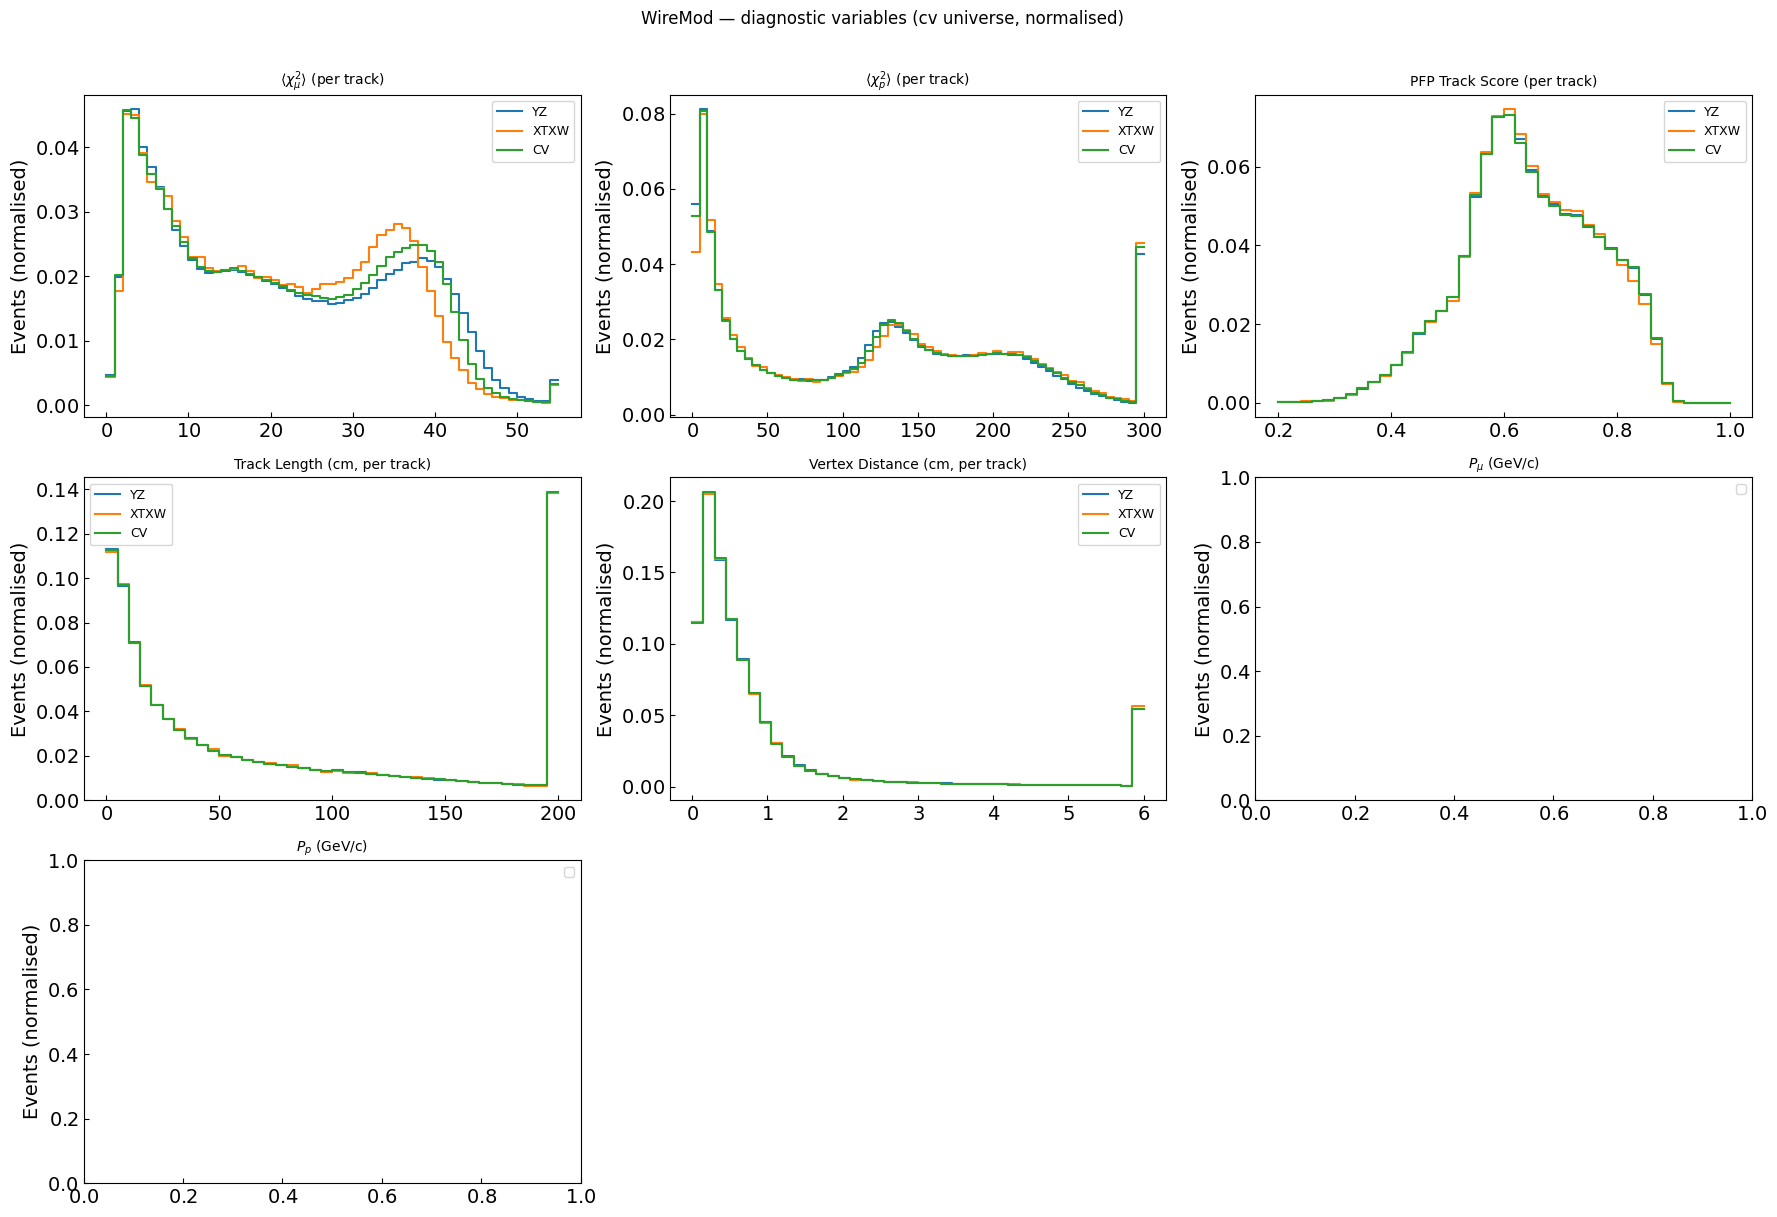

In [27]:
# ── Diagnostic variables (chi2, track score, …) ───────────────────────────────

ncols = 3
nrows = (len(DIAG_VAR_NAMES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for idx, var_name in enumerate(DIAG_VAR_NAMES):
    plot_var_comparison(var_name, PLOT_VAR_DEFS[var_name], all_hists,
                        univ="cv", ax=axes[idx], ratio=False)

for idx in range(len(DIAG_VAR_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("WireMod — diagnostic variables (cv universe, normalised)", y=1.01)
plt.tight_layout()
save_fig(fig, "diagnostic_all")
plt.show()

  saved chi2_comparison.pdf / .png


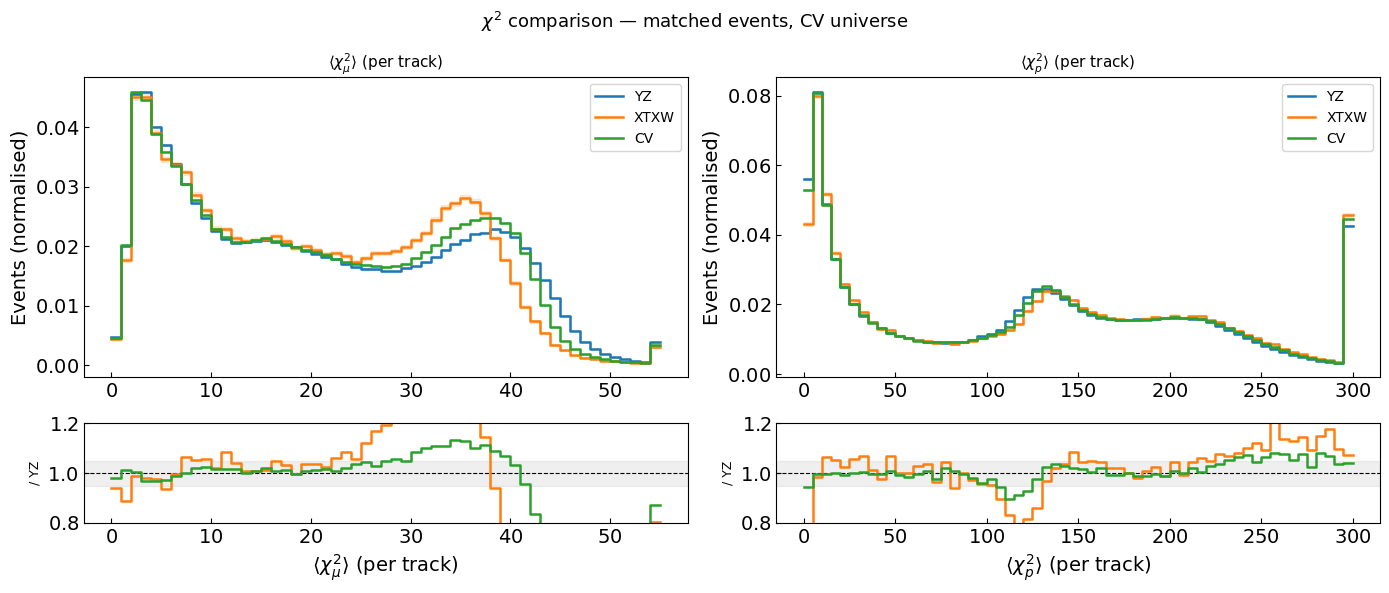

In [28]:
# ── Focused chi2 comparison with ratio panels ─────────────────────────────────

chi2_vars = {k: PLOT_VAR_DEFS[k] for k in ["chi2_mu", "chi2_p"] if k in PLOT_VAR_DEFS}

fig, axes = plt.subplots(
    2, len(chi2_vars),
    figsize=(7 * len(chi2_vars), 6),
    gridspec_kw={"height_ratios": [3, 1]},
)
if len(chi2_vars) == 1:
    axes = axes[:, np.newaxis]

for col, (var_name, var_cfg) in enumerate(chi2_vars.items()):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]
    bins    = var_cfg["bins"]
    centers = (bins[:-1] + bins[1:]) / 2

    reference_counts = None
    reference_label  = None

    for var_label, hists in all_hists.items():
        counts = hists["cv"][var_name].copy()
        total  = counts.sum()
        if total == 0:
            continue
        norm = counts / total
        err  = np.sqrt(counts) / total       # Poisson uncertainty on normalised bin
        color = VAR_COLORS.get(var_label, None)

        ax_top.step(bins, np.append(norm, norm[-1]),
                    where="post", label=var_label, color=color, linewidth=1.8)
        ax_top.fill_between(bins, np.append(norm - err, (norm - err)[-1]),
                             np.append(norm + err, (norm + err)[-1]),
                             step="post", alpha=0.15, color=color)

        if reference_counts is None:
            reference_counts = norm
            reference_label  = var_label

    ax_top.set_ylabel("Events (normalised)")
    ax_top.legend(fontsize=10)
    ax_top.set_title(var_cfg["label"], fontsize=11)

    # ratio
    ax_bot.axhline(1.0, color="k", linewidth=0.8, linestyle="--")
    ax_bot.axhspan(0.95, 1.05, color="grey", alpha=0.12)
    for var_label, hists in all_hists.items():
        if var_label == reference_label:
            continue
        counts = hists["cv"][var_name].copy()
        total  = counts.sum()
        if total == 0:
            continue
        norm = counts / total
        with np.errstate(divide="ignore", invalid="ignore"):
            rat = np.where(reference_counts > 0, norm / reference_counts, np.nan)
        color = VAR_COLORS.get(var_label, None)
        ax_bot.step(bins, np.append(rat, rat[-1]),
                    where="post", color=color, linewidth=1.8)

    ax_bot.set_ylim(0.8, 1.2)
    ax_bot.set_ylabel(f"/ {reference_label}", fontsize=9)
    ax_bot.set_xlabel(var_cfg["label"])

fig.suptitle(r"$\chi^2$ comparison — matched events, CV universe", fontsize=13)
plt.tight_layout()
save_fig(fig, "chi2_comparison")
plt.show()

  saved chi2_calo_envelope.pdf / .png


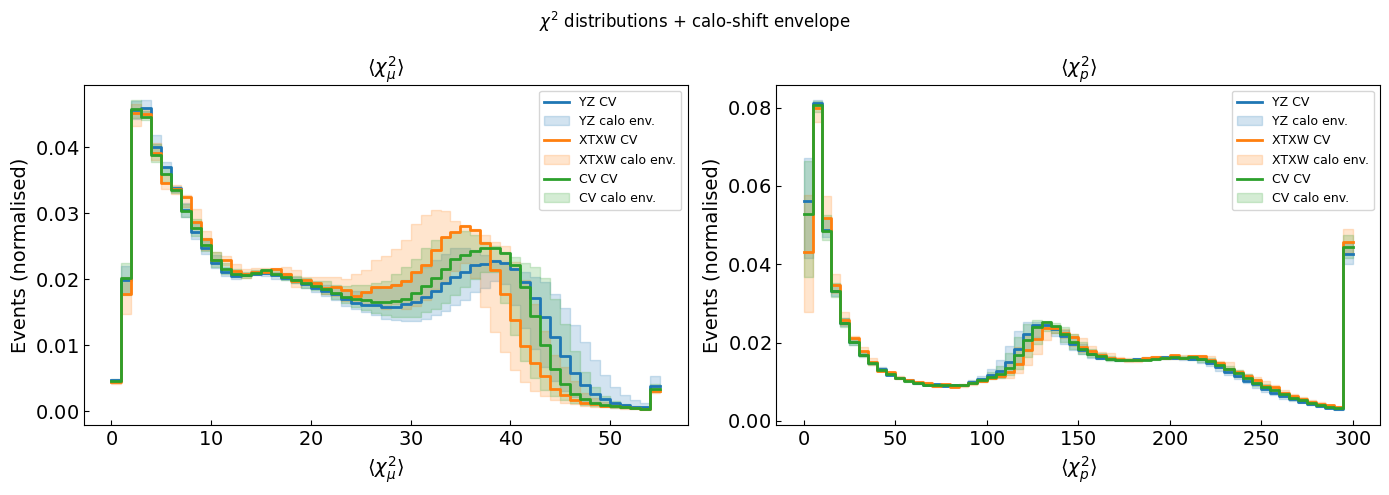

In [29]:
# ── Chi2 per-variation envelope: cv vs calo shifts within each variation ──────

example_hists = next(iter(all_hists.values()))
available_univs = [u for u in ALL_UNIVERSES if u in example_hists]
shifted_univs = [u for u in available_univs if u != "cv"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
chi2_keys = [("chi2_mu", r"$\langle\chi^2_\mu\rangle$"),
             ("chi2_p",  r"$\langle\chi^2_p\rangle$")]

for ax, (var_name, var_title) in zip(axes, chi2_keys):
    bins = PLOT_VAR_DEFS[var_name]["bins"]

    for var_label, hists in all_hists.items():
        color = VAR_COLORS.get(var_label, None)
        cv_cnt = hists["cv"][var_name]
        total = cv_cnt.sum()
        if total == 0:
            continue
        cv_norm = cv_cnt / total
        ax.step(bins, np.append(cv_norm, cv_norm[-1]),
                where="post", color=color, linewidth=2,
                label=f"{var_label} CV")

        if shifted_univs:
            shifted = np.stack(
                [hists[u][var_name] / (hists[u][var_name].sum() or 1)
                 for u in shifted_univs],
                axis=0,
            )
            lo = shifted.min(axis=0)
            hi = shifted.max(axis=0)
            ax.fill_between(bins, np.append(lo, lo[-1]), np.append(hi, hi[-1]),
                            step="post", color=color, alpha=0.2,
                            label=f"{var_label} calo env.")

    ax.set_xlabel(var_title)
    ax.set_ylabel("Events (normalised)")
    ax.legend(fontsize=9)
    ax.set_title(var_title)

fig.suptitle(r"$\chi^2$ distributions + calo-shift envelope", fontsize=12)
plt.tight_layout()
save_fig(fig, "chi2_calo_envelope")
plt.show()

/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


  saved final_selected_all.pdf / .png


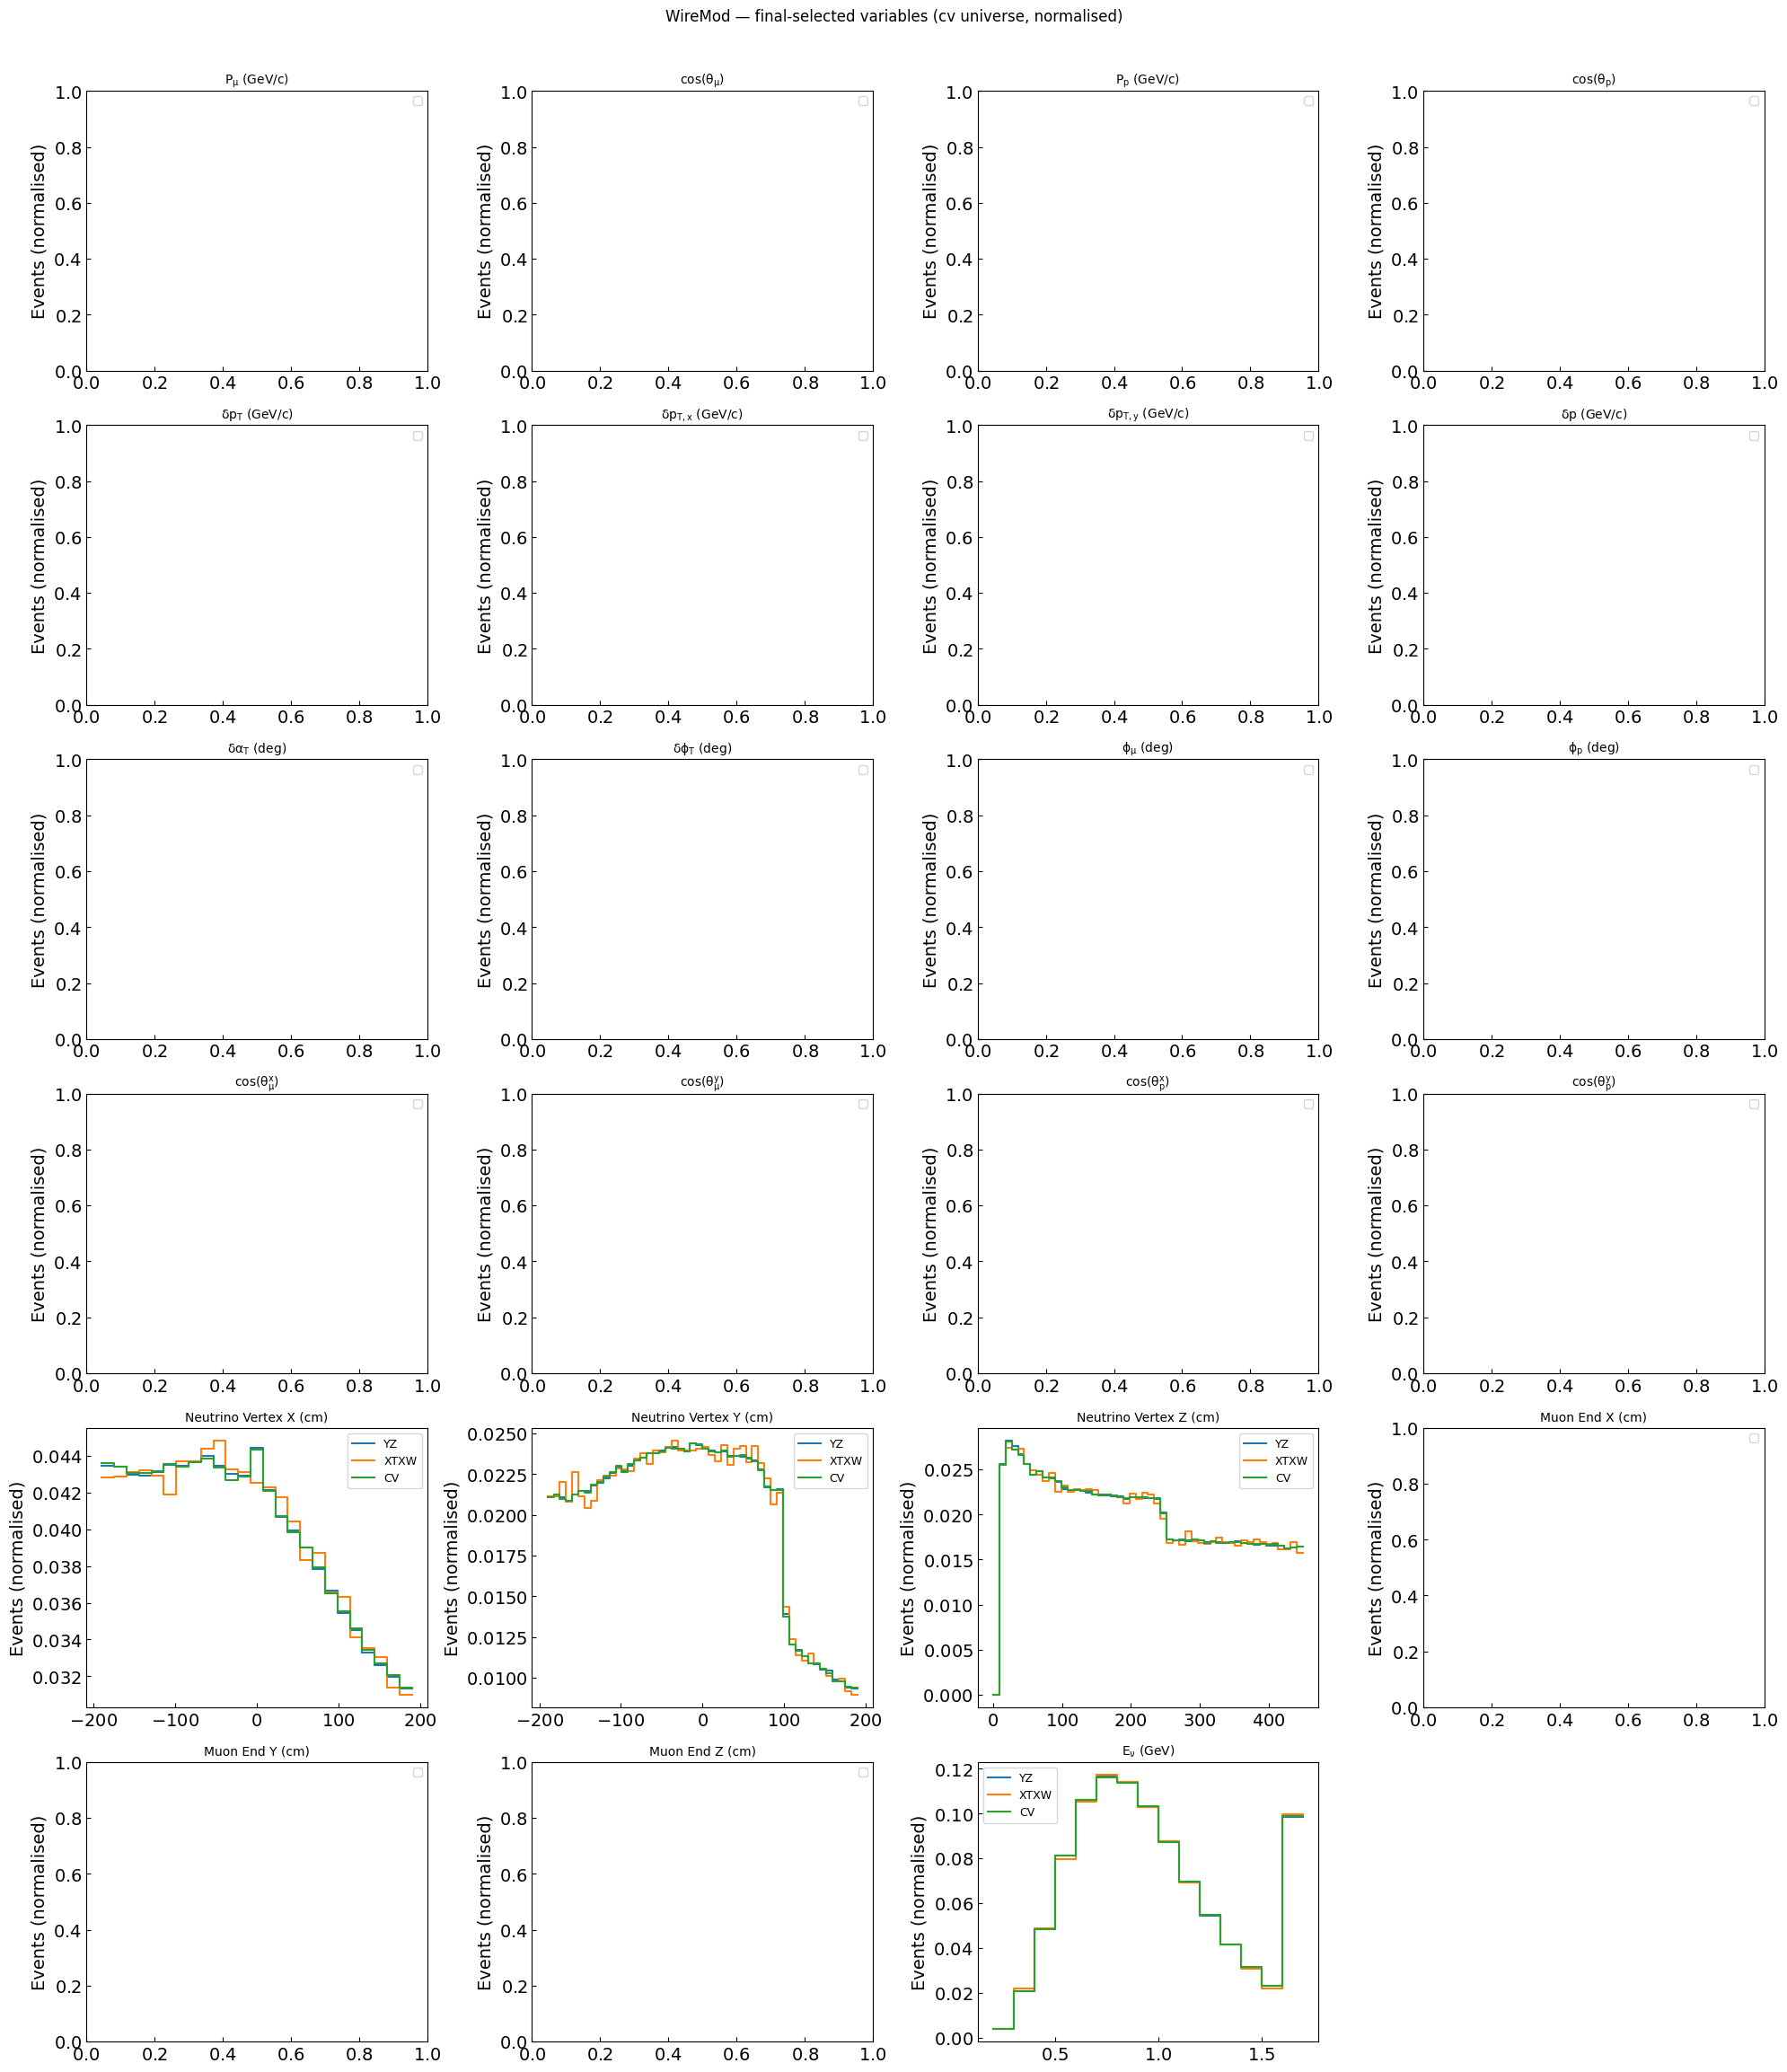

/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


  saved final_selected_muon-p.pdf / .png


/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


  saved final_selected_muon-dir_z.pdf / .png


/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


...

  saved final_selected_muon-end_x.pdf / .png


/tmp/ipykernel_1736756/3339423317.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(
/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


  saved final_selected_muon-end_y.pdf / .png


/tmp/ipykernel_1736756/3339423317.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=9)


  saved final_selected_muon-end_z.pdf / .png
  saved final_selected_E_nu.pdf / .png


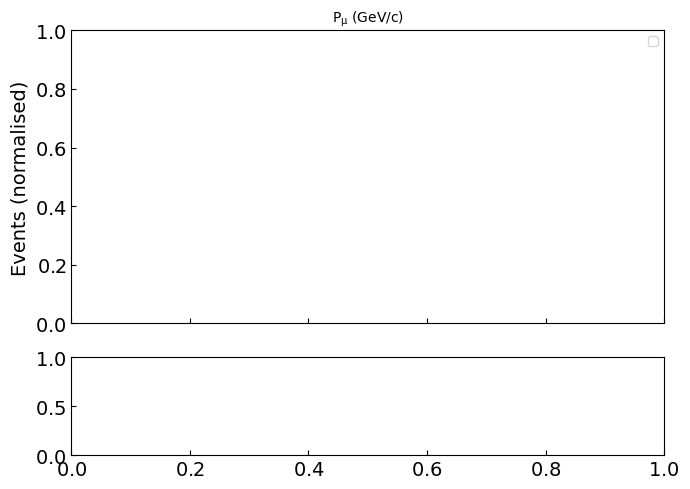

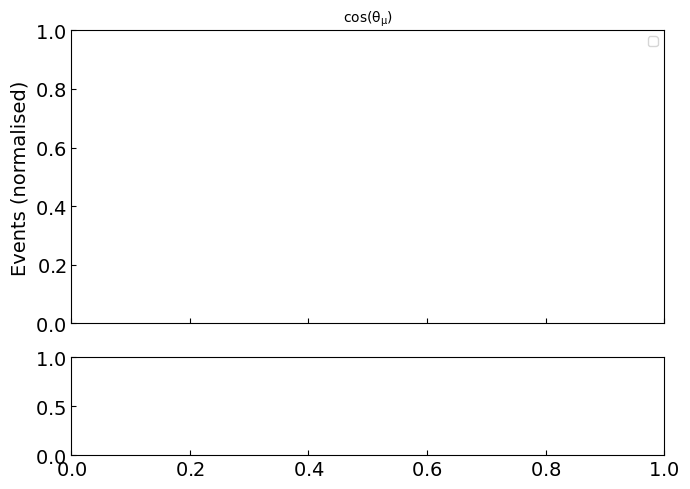

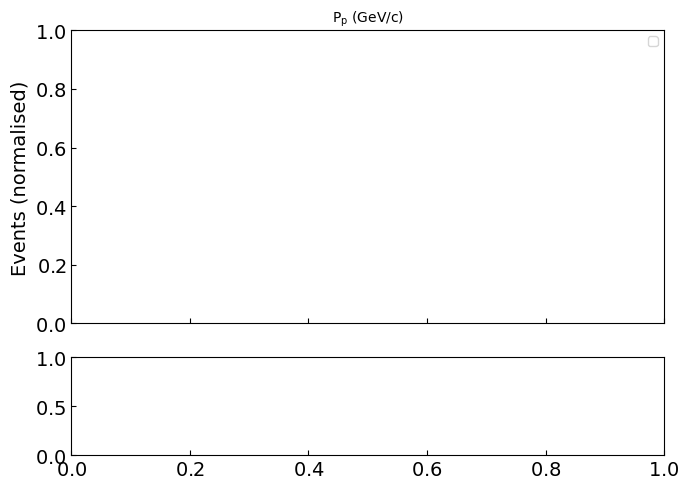

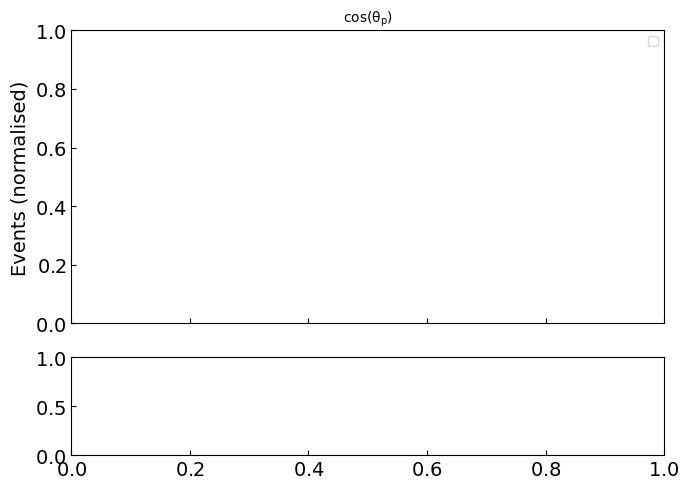

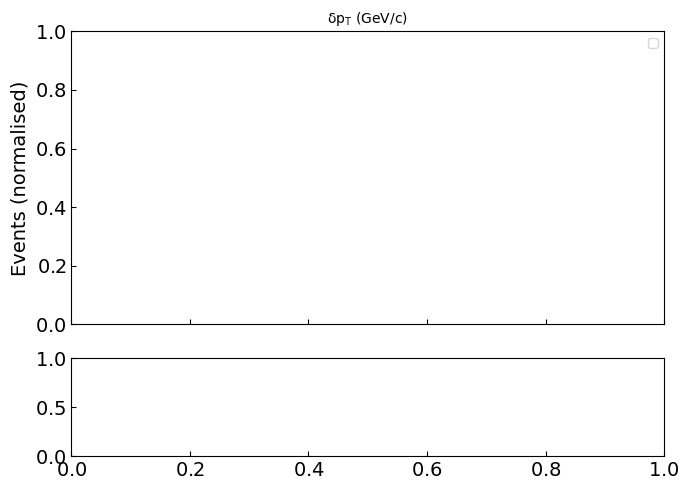

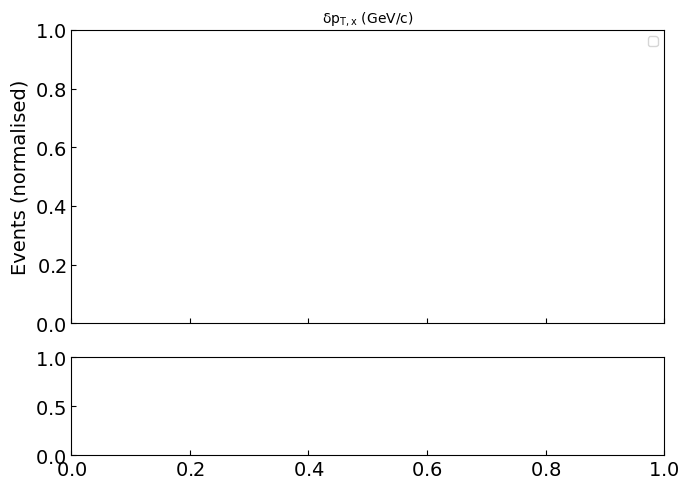

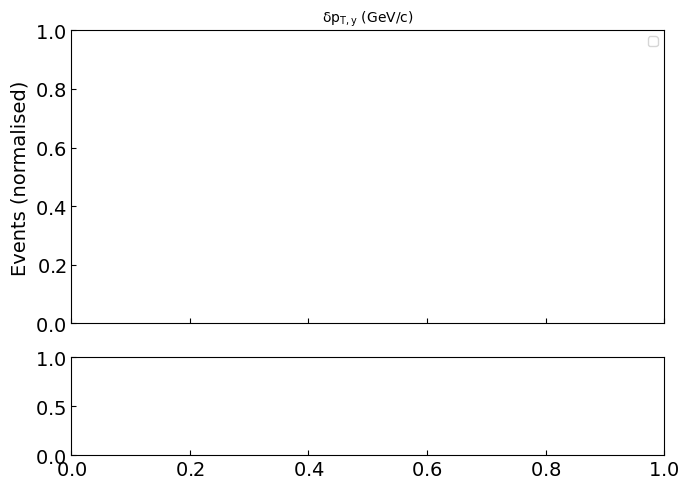

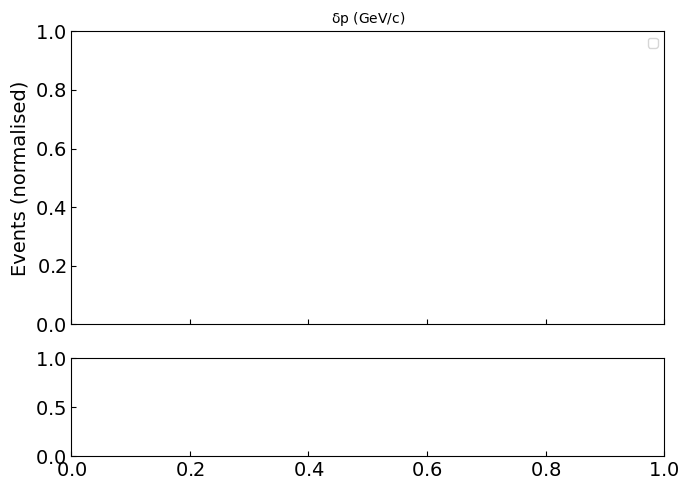

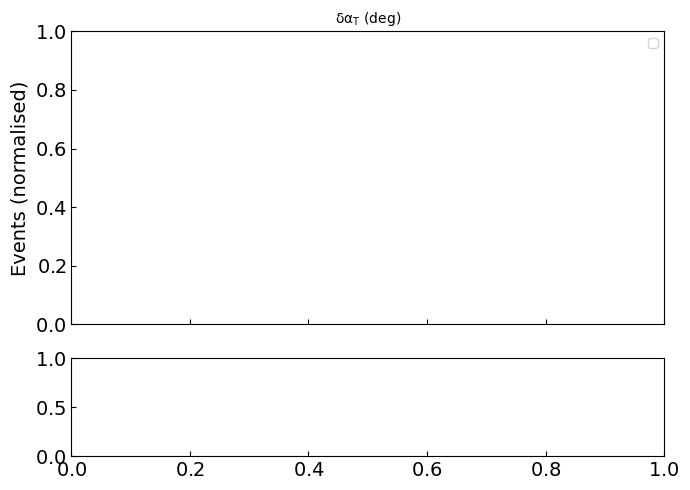

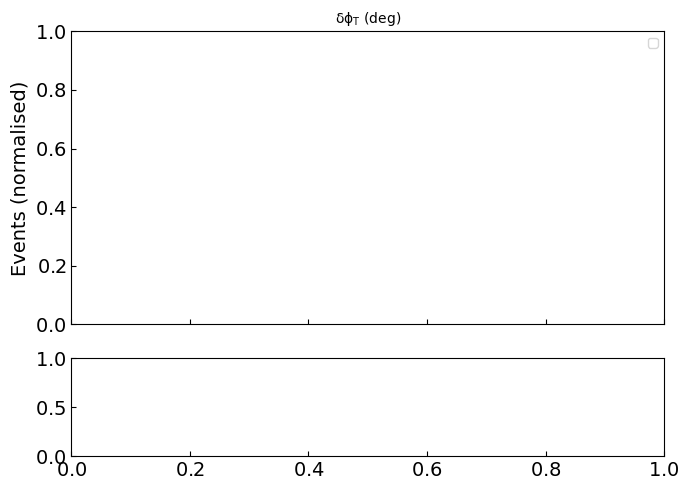

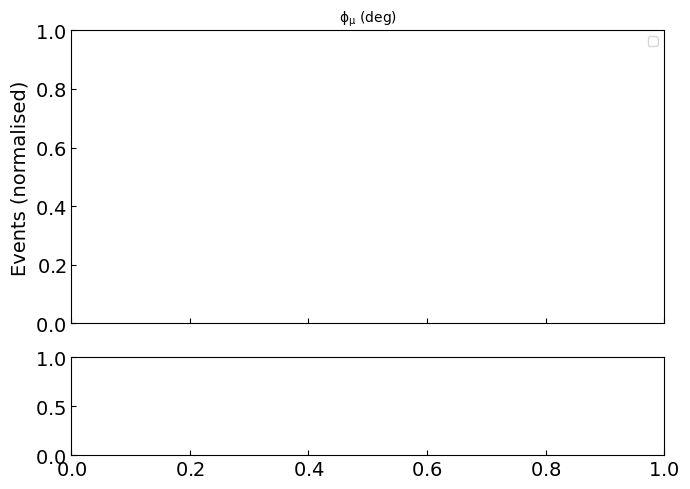

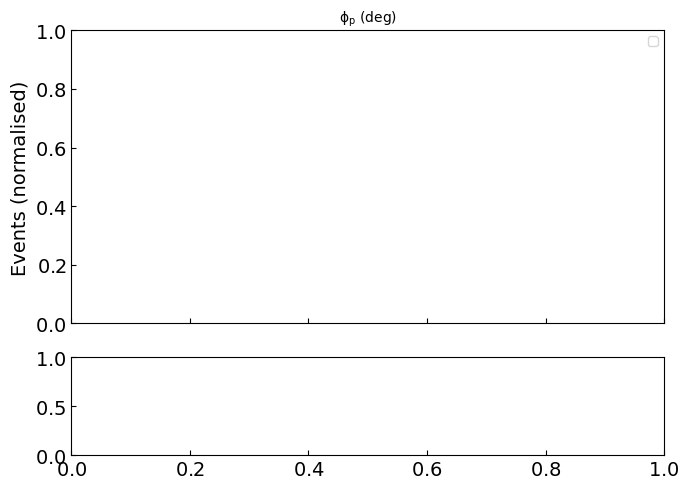

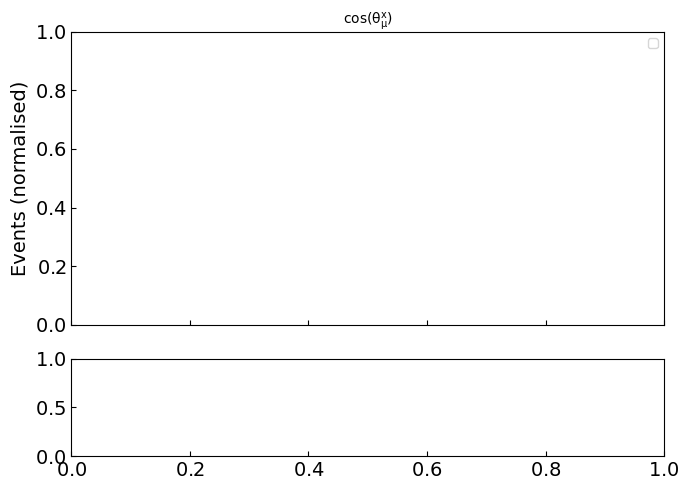

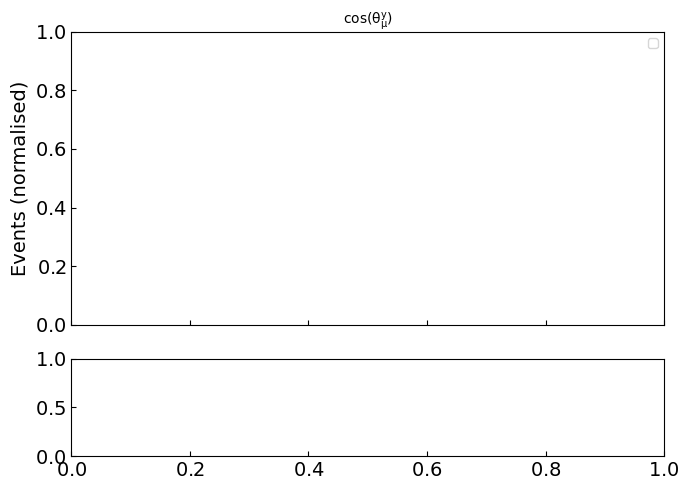

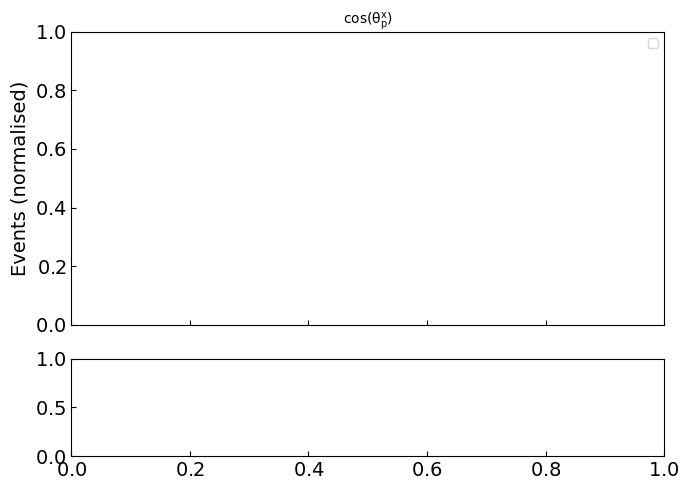

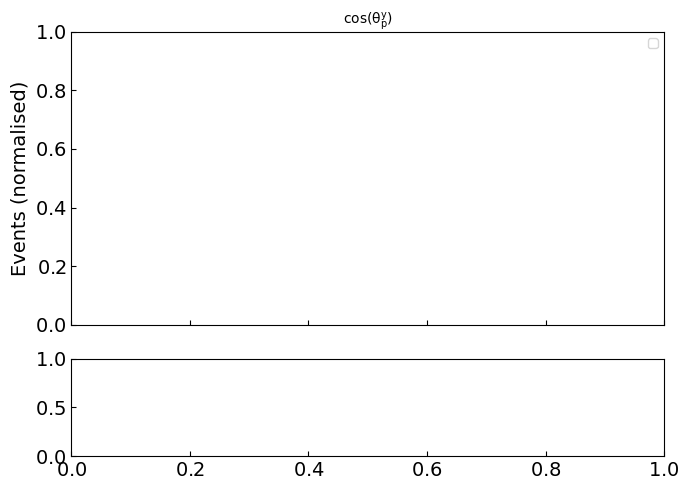

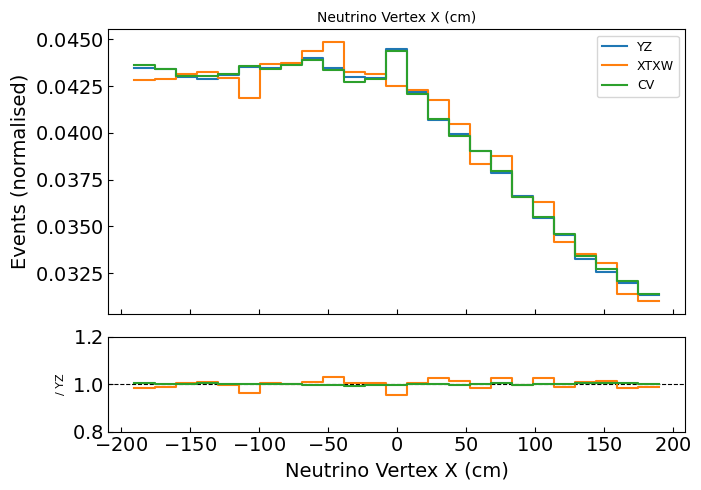

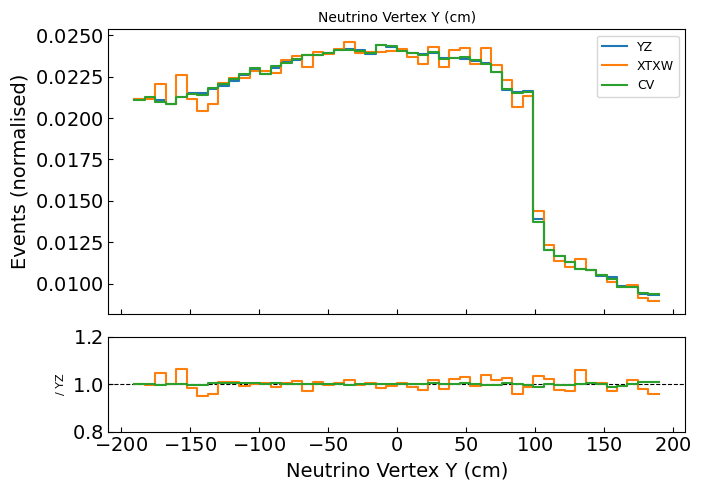

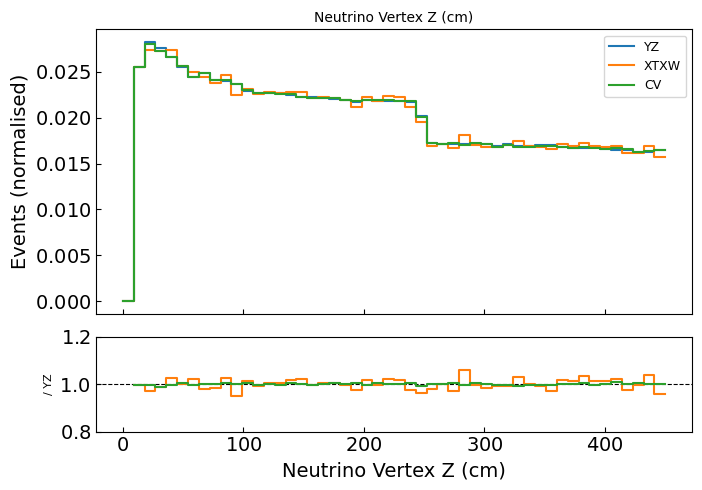

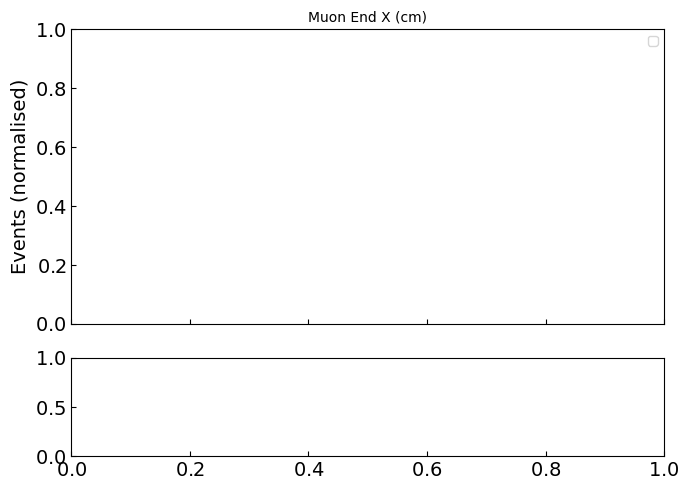

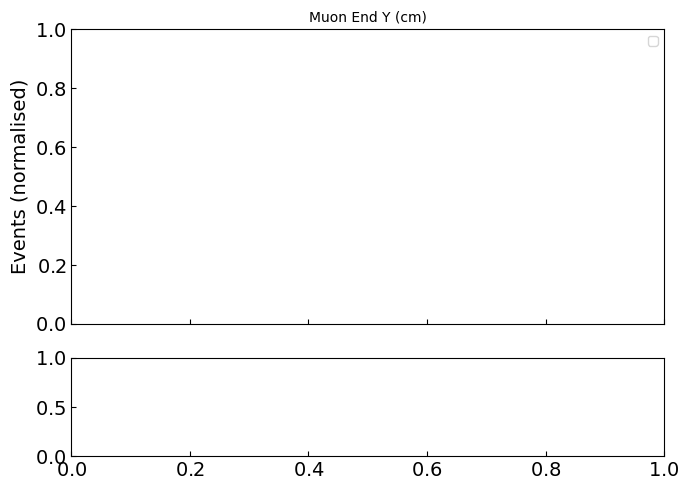

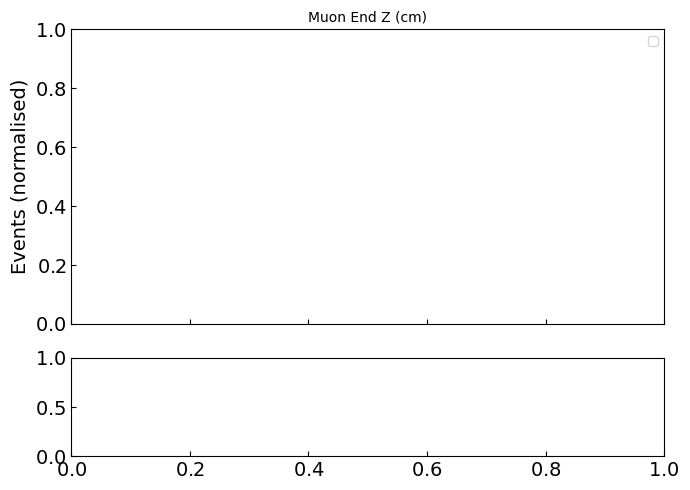

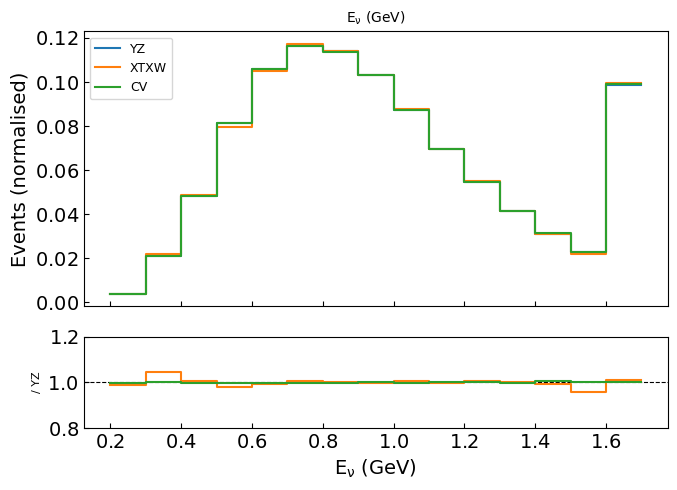

In [30]:
# ── Final-selected variables (cv universe) ────────────────────────────────────

ncols = 4
nrows = (len(FINAL_VAR_NAMES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
axes = np.array(axes).flatten()

for idx, var_name in enumerate(FINAL_VAR_NAMES):
    plot_var_comparison(var_name, PLOT_VAR_DEFS[var_name], all_hists,
                        univ="cv", ax=axes[idx], ratio=False)

for idx in range(len(FINAL_VAR_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("WireMod — final-selected variables (cv universe, normalised)", y=1.01)
plt.tight_layout()
save_fig(fig, "final_selected_all")
plt.show()

# Individual figures (easier to drop into talks)
for var_name in FINAL_VAR_NAMES:
    fig = plot_var_comparison(var_name, PLOT_VAR_DEFS[var_name], all_hists,
                              univ="cv", ratio=True)
    save_fig(fig, f"final_selected_{var_name}")

### Replot only (no file loop)

Set `RUN_ACCUMULATION = False` in the accumulation cell, then run from the **plot helpers** cell downward. Histograms are read from `CACHE_PATH`.

In [31]:
# Quick sanity check: total events and non-empty histograms per variation
for vl in all_hists:
    cv_evts = all_nevts[vl]["cv"] if vl in all_nevts else "?"
    nonempty = sum(
        1 for vn in FINAL_VAR_NAMES
        if all_hists[vl]["cv"][vn].sum() > 0
    )
    print(f"{vl}: cv events={cv_evts:,}, final vars with counts={nonempty}/{len(FINAL_VAR_NAMES)}")

YZ: cv events=1,060,330, final vars with counts=4/23
XTXW: cv events=101,186, final vars with counts=4/23
CV: cv events=1,064,695, final vars with counts=4/23
